In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

In [53]:
data = pd.read_csv("lat5Cluster.csv")
df = pd.DataFrame(data)

df.head()

,Unnamed: 0,Customer_ID,Age,Annual_Income,Spending_Score,Transactions,Region,Payment_Method,Last_Purchase
0,0,CUST001,55.0,71,2.0,57,Bekasi,E-Wallet,239.0
1,1,CUST002,45.0,115,1.0,62,Depok,E-Wallet,110.0
2,2,CUST003,31.0,151,48.0,61,Jakarta,E-Wallet,NaN
3,3,CUST004,59.0,241,12.0,21,Bekasi,E-Wallet,150.0
4,4,CUST005,24.0,248,NaN,999,Jakarta,Transfer,182.0


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      150 non-null    int64  
 1   Customer_ID     150 non-null    str    
 2   Age             150 non-null    float64
 3   Annual_Income   150 non-null    int64  
 4   Spending_Score  150 non-null    float64
 5   Transactions    150 non-null    int64  
 6   Region          150 non-null    str    
 7   Payment_Method  150 non-null    str    
 8   Last_Purchase   150 non-null    float64
 9   Cluster         150 non-null    int32  
dtypes: float64(3), int32(1), int64(3), str(3)
memory usage: 11.3 KB


In [54]:
df.isnull().sum()

Unnamed: 0         0
Customer_ID        0
Age               15
Annual_Income      0
Spending_Score    15
Transactions       0
Region             0
Payment_Method     0
Last_Purchase     15
dtype: int64

In [55]:
# fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Spending_Score"] = df["Spending_Score"].fillna(df["Spending_Score"].mean())
df["Last_Purchase"] = df["Last_Purchase"].fillna(df["Last_Purchase"].mode()[0])

df.isnull().sum()

Unnamed: 0        0
Customer_ID       0
Age               0
Annual_Income     0
Spending_Score    0
Transactions      0
Region            0
Payment_Method    0
Last_Purchase     0
dtype: int64

In [56]:
df["Region"] = df["Region"].str.title()
df.head()

,Unnamed: 0,Customer_ID,Age,Annual_Income,Spending_Score,Transactions,Region,Payment_Method,Last_Purchase
0,0,CUST001,55.0,71,2.000000,57,Bekasi,E-Wallet,239.0
1,1,CUST002,45.0,115,1.000000,62,Depok,E-Wallet,110.0
2,2,CUST003,31.0,151,48.000000,61,Jakarta,E-Wallet,110.0
3,3,CUST004,59.0,241,12.000000,21,Bekasi,E-Wallet,150.0
4,4,CUST005,24.0,248,48.185185,999,Jakarta,Transfer,182.0


In [57]:
Q1 = df["Spending_Score"].quantile(0.25)
Q3 = df["Spending_Score"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[
    (df["Spending_Score"] < lower_bound) | (df["Spending_Score"] > upper_bound)
]

df.head()

,Unnamed: 0,Customer_ID,Age,Annual_Income,Spending_Score,Transactions,Region,Payment_Method,Last_Purchase
0,0,CUST001,55.0,71,2.000000,57,Bekasi,E-Wallet,239.0
1,1,CUST002,45.0,115,1.000000,62,Depok,E-Wallet,110.0
2,2,CUST003,31.0,151,48.000000,61,Jakarta,E-Wallet,110.0
3,3,CUST004,59.0,241,12.000000,21,Bekasi,E-Wallet,150.0
4,4,CUST005,24.0,248,48.185185,999,Jakarta,Transfer,182.0


In [58]:
df["Region"].unique()

<StringArray>
['Bekasi', 'Depok', 'Jakarta', 'Bandung']
Length: 4, dtype: str

In [59]:
df["Payment_Method"].unique()

<StringArray>
['E-Wallet', 'Transfer', 'COD']
Length: 3, dtype: str

In [65]:
from sklearn.tree import DecisionTreeClassifier

df_encoded = df.copy()

df_encoded["Region"] = df_encoded["Region"].map(
    {
        "Jakarta": 3,
        "Bekasi": 2,
        "Bandung": 1,
        "Depok": 0,
    }
)

df_encoded["Payment_Method"] = df_encoded["Payment_Method"].map(
    {
        "E-Wallet": 2,
        "Transfer": 1,
        "COD": 0,
    }
)

df_encoded

,Unnamed: 0,Customer_ID,Age,Annual_Income,Spending_Score,Transactions,Region,Payment_Method,Last_Purchase,Cluster
0,0,CUST001,55.0,71,2.000000,57,2,2,239.0,1
1,1,CUST002,45.0,115,1.000000,62,0,2,110.0,1
2,2,CUST003,31.0,151,48.000000,61,3,2,110.0,1
3,3,CUST004,59.0,241,12.000000,21,2,2,150.0,0
4,4,CUST005,24.0,248,48.185185,999,3,1,182.0,2
...,...,...,...,...,...,...,...,...,...,...
145,145,CUST146,42.0,26,87.000000,51,2,2,219.0,0
146,146,CUST147,58.0,163,63.000000,15,2,1,74.0,0
147,147,CUST148,29.0,109,86.000000,68,2,2,3.0,0
148,148,CUST149,48.0,131,48.185185,11,3,0,334.0,0


In [68]:
x = df_encoded[
    [
        "Age",
        "Annual_Income",
        "Spending_Score",
        "Last_Purchase",
        "Region",
        "Payment_Method",
        "Last_Purchase",
    ]
]
y = df_encoded["Cluster"]

model = DecisionTreeClassifier()
model.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

y_pred = model.predict(x_test)
cleaned_accuracy = accuracy_score(y_test, y_pred)
print("Akurasi setelah pembersihan data:", cleaned_accuracy)

Akurasi setelah pembersihan data: 1.0


In [61]:
features = ["Age", "Annual_Income", "Spending_Score", "Transactions"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()

,Age,Annual_Income,Spending_Score,Transactions
0,0.980577,-0.754439,-1.706258e+00,0.162780
1,0.333252,-0.400595,-1.743202e+00,0.224037
2,-0.573002,-0.111086,-6.841453e-03,0.211786
3,1.239507,0.612687,-1.336820e+00,-0.278270
4,-1.026129,0.668980,-2.625018e-16,11.703601


In [62]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

df["Cluster"] = kmeans.labels_
df.head()

,Unnamed: 0,Customer_ID,Age,Annual_Income,Spending_Score,Transactions,Region,Payment_Method,Last_Purchase,Cluster
0,0,CUST001,55.0,71,2.000000,57,Bekasi,E-Wallet,239.0,1
1,1,CUST002,45.0,115,1.000000,62,Depok,E-Wallet,110.0,1
2,2,CUST003,31.0,151,48.000000,61,Jakarta,E-Wallet,110.0,1
3,3,CUST004,59.0,241,12.000000,21,Bekasi,E-Wallet,150.0,0
4,4,CUST005,24.0,248,48.185185,999,Jakarta,Transfer,182.0,2


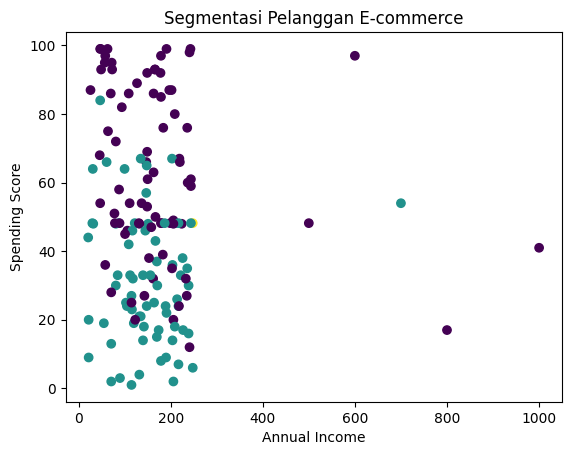

In [63]:
plt.Figure()
plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Segmentasi Pelanggan E-commerce")
plt.show()

In [64]:
# df.groupby("Cluster").mean(numeric_only=True)
# or
df.groupby("Cluster")[
    ["Age", "Annual_Income", "Spending_Score", "Last_Purchase"]
].mean()

,Age,Annual_Income,Spending_Score,Last_Purchase
Cluster,,,,
0,48.664292,176.294872,63.067901,154.717949
1,30.393845,151.028169,31.835159,166.014085
2,24.000000,248.000000,48.185185,182.000000
